# Voronoi Diagrams

This notebook shows how Voronoi diagrams can be built based on the points of interest. Points of interest (POI) are physical objects on the map, e.g., restaurants, bars, offices, buildings, etc. The POI can be directly used as generators for Voronoi diagrams. Alternatively, if there are many POI, they can be clustered, and the cluster centroids can be used as generators for Voronoi diagrams. The latter is a more typical case.

The POI are retrieved from the richest open-source spatial database in the world, i.e., the OpenStreetMap database. We use top-level POI categories of OSM for retrieving data. A complete list of these categories can be found at [OSM wiki](https://wiki.openstreetmap.org/wiki/Map_features).

To run this notebook, in addition to `tesspy`, you need `contextily` for basemap visualization. This package is only used to enhance visualization and does not affect tessellation.

## Area

As a case study, we use **Hanau**, a city in Hesse, Germany.

In [ ]:
from tesspy import Tessellation
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (8, 8)
import contextily as ctx

In [3]:
# Create a tessellation object
hanau = Tessellation("Hanau, Germany")

# get polygon of the investigated area
hanau_polygon = hanau.get_polygon()

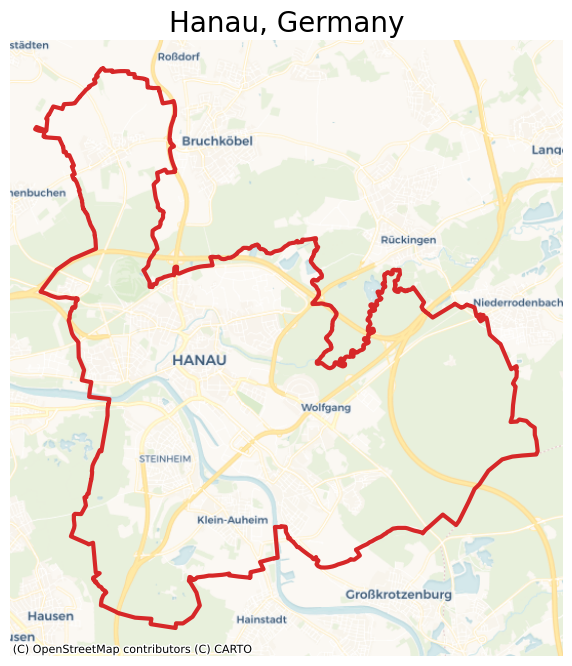

In [4]:
# visualization of area
ax = hanau_polygon.to_crs("EPSG:3857").plot(facecolor="none", edgecolor="tab:red", lw=3)
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
ax.set_axis_off()
ax.set_title("Hanau, Germany", fontsize=20)
plt.show()

## POI Categories

We can specify the desired POI categories by creating a list of them and passing it to the `poi_categories` keyword. We can investigate the possible options by:

In [5]:
hanau.osm_primary_features()

['aerialway',
 'aeroway',
 'amenity',
 'barrier',
 'boundary',
 'building',
 'craft',
 'emergency',
 'geological',
 'healthcare',
 'highway',
 'historic',
 'landuse',
 'leisure',
 'man_made',
 'military',
 'natural',
 'office',
 'place',
 'power',
 'public_transport',
 'railway',
 'route',
 'shop',
 'sport',
 'telecom',
 'tourism',
 'water',
 'waterway']

For example, we can select `office`, and `amenity`.

In [6]:
hanau_vor = hanau.voronoi(n_polygons=500, poi_categories=["office", "amenity"])

2026-02-22 14:17:09 | INFO | tesspy.tessellation | event=voronoi.start cluster_algo=k-means poi_categories=2 n_polygons=500 min_cluster_size=15 timeout_s=300
2026-02-22 14:17:09 | INFO | tesspy.data.poi | event=poi.fetch.start poi_categories=2 timeout_s=300
2026-02-22 14:17:09 | INFO | tesspy.data.poi | event=poi.fetch.done features=3641 duration_s=0.286
2026-02-22 14:17:09 | INFO | tesspy.data.poi | event=poi.parse.done poi_count=3641
2026-02-22 14:17:09 | INFO | tesspy.tessellation | event=voronoi.cluster.start algo=kmeans
2026-02-22 14:17:09 | INFO | tesspy.tessellation | event=voronoi.polygons.create generators=500
2026-02-22 14:17:09 | INFO | tesspy._validators | event=geometry.multipolygon.explode
2026-02-22 14:17:09 | INFO | tesspy.tessellation | event=voronoi.done polygons=507 duration_s=0.600


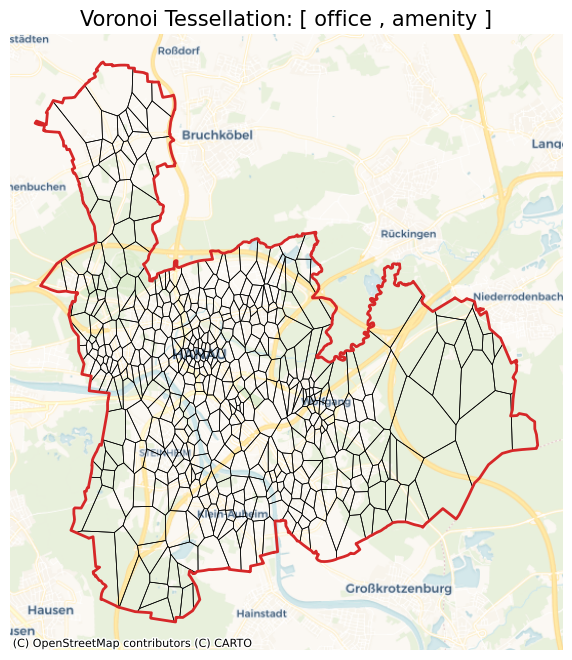

In [7]:
ax = hanau_vor.to_crs("EPSG:3857").plot(facecolor="none", edgecolor="k", lw=0.5)
hanau_polygon.to_crs("EPSG:3857").plot(
    ax=ax, facecolor="none", edgecolor="tab:red", lw=2
)
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
ax.set_axis_off()
ax.set_title("Voronoi Tessellation: [ office , amenity ]", fontsize=15)
plt.show()

We can build other Voronoi diagrams with different POI categories. For example, with `shop`, `leisure`, and `amenity`. Please note, the `amenity` POI are already retrieved from the last request and saved in the object. This request retrieves only `shop` and `leisure` data from the OSM.

In [8]:
hanau_vor = hanau.voronoi(n_polygons=500, poi_categories=["shop", "leisure", "amenity"])

2026-02-22 14:17:10 | INFO | tesspy.tessellation | event=voronoi.start cluster_algo=k-means poi_categories=3 n_polygons=500 min_cluster_size=15 timeout_s=300
2026-02-22 14:17:10 | INFO | tesspy.data.poi | event=poi.fetch.start poi_categories=2 timeout_s=300
2026-02-22 14:17:10 | INFO | tesspy.data.poi | event=poi.fetch.done features=966 duration_s=0.097
2026-02-22 14:17:10 | INFO | tesspy.data.poi | event=poi.parse.done poi_count=966
2026-02-22 14:17:10 | INFO | tesspy.tessellation | event=voronoi.cluster.start algo=kmeans
2026-02-22 14:17:10 | INFO | tesspy.tessellation | event=voronoi.polygons.create generators=500
2026-02-22 14:17:10 | INFO | tesspy._validators | event=geometry.multipolygon.explode
2026-02-22 14:17:10 | INFO | tesspy.tessellation | event=voronoi.done polygons=509 duration_s=0.250


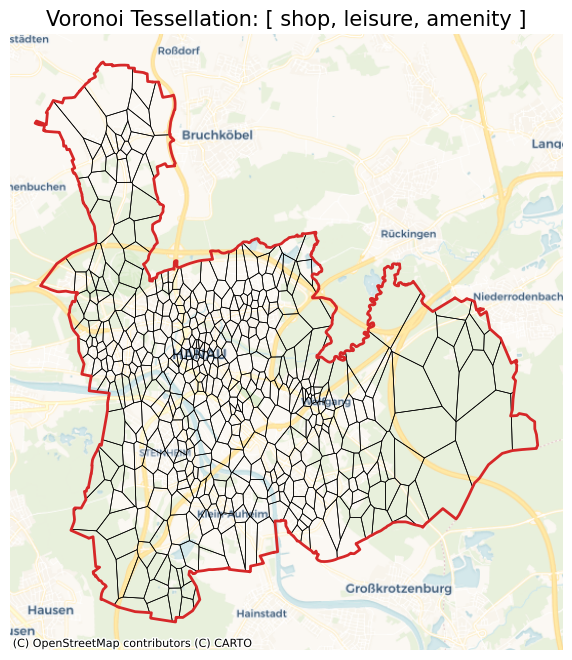

In [9]:
ax = hanau_vor.to_crs("EPSG:3857").plot(facecolor="none", edgecolor="k", lw=0.5)
hanau_polygon.to_crs("EPSG:3857").plot(
    ax=ax, facecolor="none", edgecolor="tab:red", lw=2
)
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
ax.set_axis_off()
ax.set_title("Voronoi Tessellation: [ shop, leisure, amenity ]", fontsize=15)
plt.show()

If we set POI categories as `all`, all the POI are retrieved from the OSM. It is recommended to do this initially so that all POI data are retrieved and saved in the object. After that, we can play around with poi_categories, the number of polygons, and the clustering algorithm without sending a request to OSM. This makes the whole process faster as it avoids multiple requests. This way, we could also prevent consequent requests on OSM that may result in a Runtime error for overloading the server.

Getting all the POI data can take a few minutes. Therefore, we set the verbose to `True` to track the process.

In [12]:
hanau_vor = hanau.voronoi(n_polygons=500, poi_categories="all", verbose=True, timeout=600)

2026-02-22 14:30:42 | INFO | tesspy.tessellation | event=voronoi.start cluster_algo=k-means poi_categories=29 n_polygons=500 min_cluster_size=15 timeout_s=600
2026-02-22 14:30:42 | INFO | tesspy.data.poi | event=poi.fetch.start poi_categories=25 timeout_s=600
2026-02-22 14:41:03 | INFO | tesspy.data.poi | event=poi.fetch.done features=58608 duration_s=621.450
2026-02-22 14:41:03 | INFO | tesspy.data.poi | event=poi.parse.done poi_count=58608
2026-02-22 14:41:04 | INFO | tesspy.tessellation | event=voronoi.cluster.start algo=kmeans
2026-02-22 14:41:05 | INFO | tesspy.tessellation | event=voronoi.polygons.create generators=500
2026-02-22 14:41:05 | INFO | tesspy._validators | event=geometry.multipolygon.explode
2026-02-22 14:41:05 | INFO | tesspy.tessellation | event=voronoi.done polygons=471 duration_s=622.893


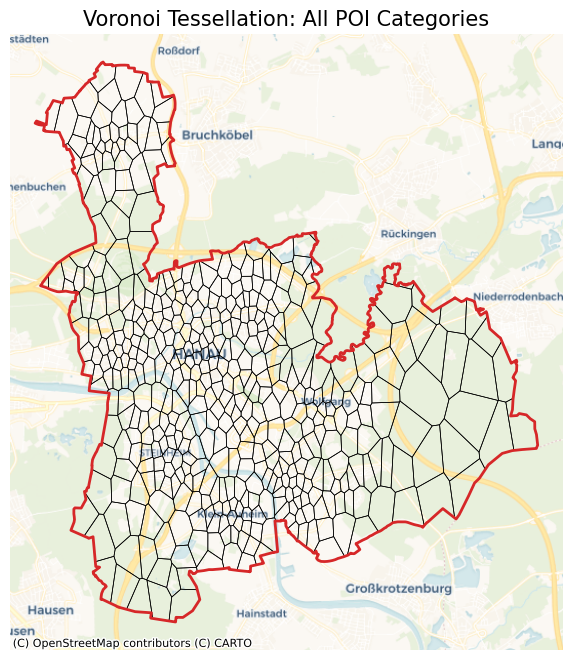

In [13]:
ax = hanau_vor.to_crs("EPSG:3857").plot(facecolor="none", edgecolor="k", lw=0.5)
hanau_polygon.to_crs("EPSG:3857").plot(
    ax=ax, facecolor="none", edgecolor="tab:red", lw=2
)
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
ax.set_axis_off()
ax.set_title("Voronoi Tessellation: All POI Categories", fontsize=15)
plt.show()

All the POI are now collected and saved in the Tessellation object. We can call the POI data by:

In [14]:
hanau_poi_data = hanau.get_poi_data()
hanau_poi_data.head()

,center_longitude,center_latitude,office,amenity,shop,leisure,aerialway,aeroway,barrier,boundary,...,place,power,public_transport,railway,route,sport,telecom,tourism,water,waterway
0,8.908874,50.146012,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,8.930772,50.121349,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,8.886054,50.126376,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,8.884959,50.142497,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,8.894138,50.143121,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


We can now test different Voronoi tessellations with different POI categories without having to get data again from the OSM. We create 1000 Voronoi polygons with all the POI data again. As can be seen by verbose, data collection is skipped.

In [15]:
hanau_vor = hanau.voronoi(n_polygons=1000, poi_categories="all", verbose=True)

2026-02-22 14:41:17 | INFO | tesspy.tessellation | event=voronoi.start cluster_algo=k-means poi_categories=29 n_polygons=1000 min_cluster_size=15 timeout_s=300
2026-02-22 14:41:17 | INFO | tesspy.tessellation | event=voronoi.cluster.start algo=kmeans
2026-02-22 14:41:19 | INFO | tesspy.tessellation | event=voronoi.polygons.create generators=1000
2026-02-22 14:41:19 | INFO | tesspy._validators | event=geometry.multipolygon.explode
2026-02-22 14:41:19 | INFO | tesspy.tessellation | event=voronoi.done polygons=958 duration_s=2.046


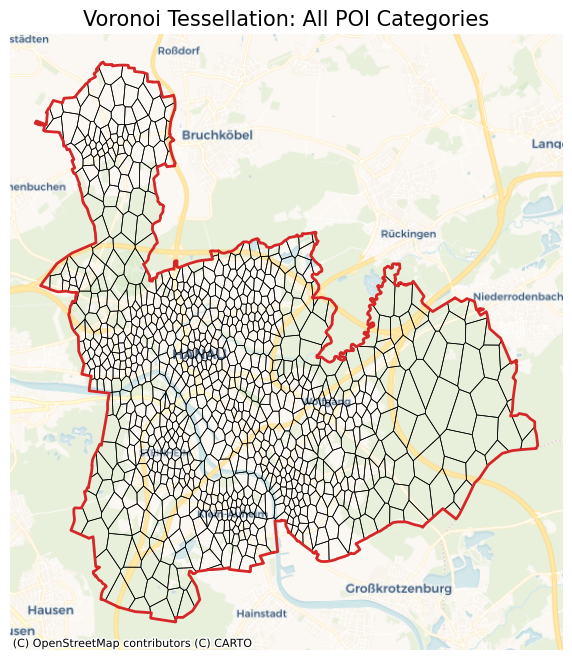

In [16]:
ax = hanau_vor.to_crs("EPSG:3857").plot(facecolor="none", edgecolor="k", lw=0.5)
hanau_polygon.to_crs("EPSG:3857").plot(
    ax=ax, facecolor="none", edgecolor="tab:red", lw=2
)
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
ax.set_axis_off()
ax.set_title("Voronoi Tessellation: All POI Categories", fontsize=15)
plt.show()

## Number of Polygons


Voronoi polygons need a list of generators to be built. The number of polygons is the number of generators. Please note that the keyword `n_polygons` is an approximate number. In order to have more accurate results, always a bigger area (buffered area) than the investigated area is analyzed. The reason is to have reasonable polygons on the borders.

The final number of created Voronoi polygons is usually smaller than `n_polygons`. We can play around with the number to get the desired results.

Let's create 100, 500, and 1000 polygons using only `building`s. 

In [17]:
hanau_vor_100_buildings = hanau.voronoi(n_polygons=100, poi_categories=["building"])
hanau_vor_500_buildings = hanau.voronoi(n_polygons=500, poi_categories=["building"])
hanau_vor_1000_buildings = hanau.voronoi(n_polygons=1000, poi_categories=["building"])

2026-02-22 14:41:23 | INFO | tesspy.tessellation | event=voronoi.start cluster_algo=k-means poi_categories=1 n_polygons=100 min_cluster_size=15 timeout_s=300
2026-02-22 14:41:23 | INFO | tesspy.tessellation | event=voronoi.cluster.start algo=kmeans
2026-02-22 14:41:23 | INFO | tesspy.tessellation | event=voronoi.polygons.create generators=100
2026-02-22 14:41:23 | INFO | tesspy._validators | event=geometry.multipolygon.explode
2026-02-22 14:41:23 | INFO | tesspy.tessellation | event=voronoi.done polygons=103 duration_s=0.148
2026-02-22 14:41:23 | INFO | tesspy.tessellation | event=voronoi.start cluster_algo=k-means poi_categories=1 n_polygons=500 min_cluster_size=15 timeout_s=300
2026-02-22 14:41:23 | INFO | tesspy.tessellation | event=voronoi.cluster.start algo=kmeans
2026-02-22 14:41:23 | INFO | tesspy.tessellation | event=voronoi.polygons.create generators=500
2026-02-22 14:41:23 | INFO | tesspy._validators | event=geometry.multipolygon.explode
2026-02-22 14:41:23 | INFO | tesspy.te

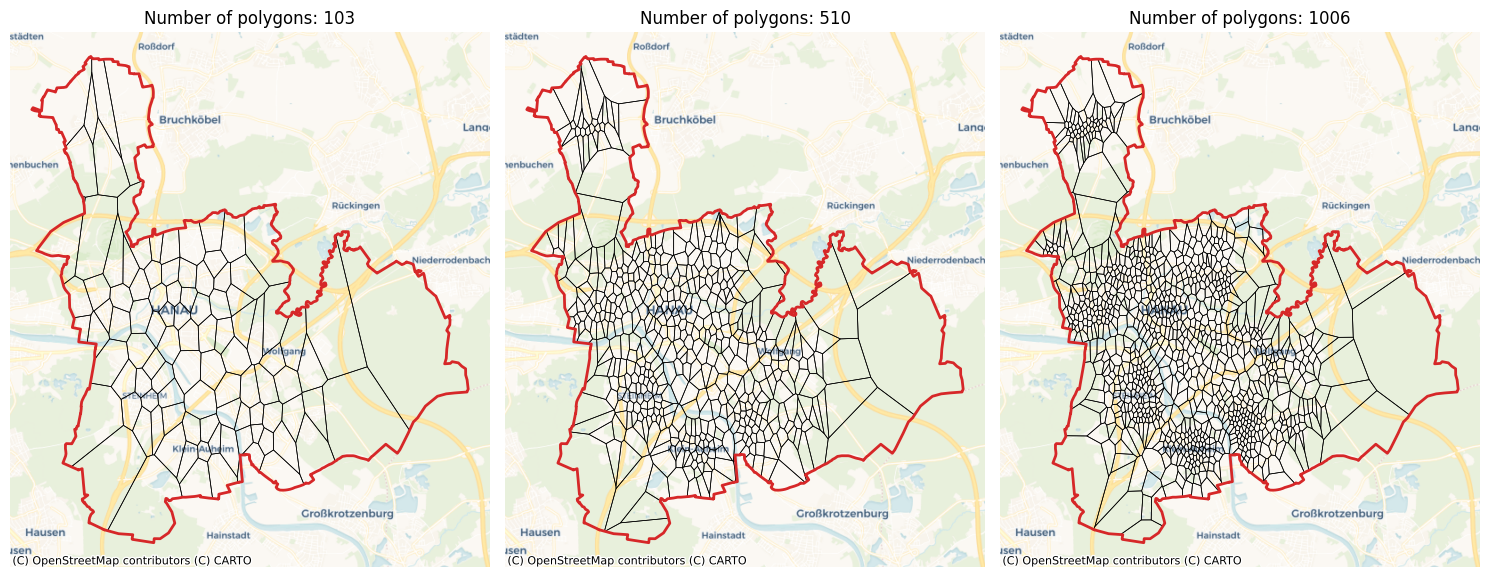

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

hanau_vor_100_buildings.to_crs("EPSG:3857").plot(
    ax=axs[0], facecolor="none", edgecolor="k", lw=0.5
)
hanau_vor_500_buildings.to_crs("EPSG:3857").plot(
    ax=axs[1], facecolor="none", edgecolor="k", lw=0.5
)
hanau_vor_1000_buildings.to_crs("EPSG:3857").plot(
    ax=axs[2], facecolor="none", edgecolor="k", lw=0.5
)

axs[0].set_title(f"Number of polygons: {len(hanau_vor_100_buildings)}")
axs[1].set_title(f"Number of polygons: {len(hanau_vor_500_buildings)}")
axs[2].set_title(f"Number of polygons: {len(hanau_vor_1000_buildings)}")

for ax in axs.flatten():
    ax.set_axis_off()
    ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
    hanau_polygon.to_crs("EPSG:3857").plot(
        ax=ax, facecolor="none", edgecolor="tab:red", lw=2
    )

plt.tight_layout()

## Clustering Algorithms

The Voronoi generators can be directly set as the POI coordinates. This can be done by setting the `cluster_algo` to `None`. For example, we can create Voronoi polygons with `leisure` as generators. 

In [19]:
hanau_vor_leisure = hanau.voronoi(cluster_algo=None, poi_categories=["leisure"])

2026-02-22 14:41:37 | INFO | tesspy.tessellation | event=voronoi.start cluster_algo=None poi_categories=1 n_polygons=100 min_cluster_size=15 timeout_s=300
2026-02-22 14:41:37 | INFO | tesspy.tessellation | event=voronoi.polygons.create generators=433
2026-02-22 14:41:37 | INFO | tesspy._validators | event=geometry.multipolygon.explode
2026-02-22 14:41:37 | INFO | tesspy.tessellation | event=voronoi.done polygons=443 duration_s=0.063


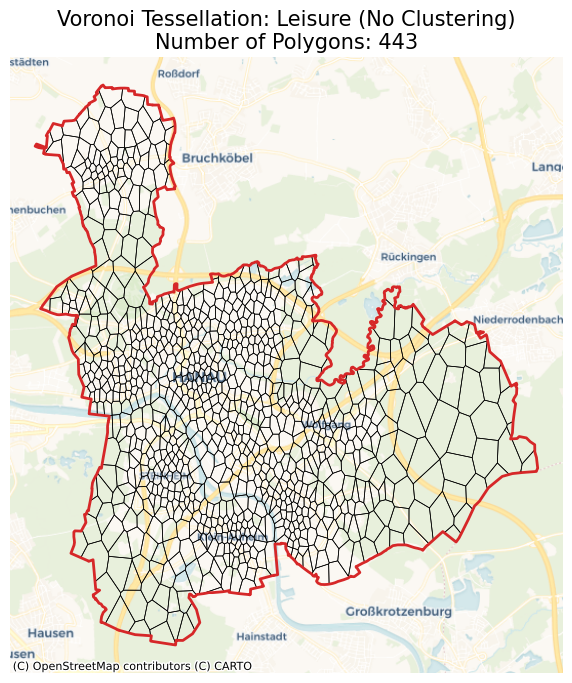

In [20]:
ax = hanau_vor.to_crs("EPSG:3857").plot(facecolor="none", edgecolor="k", lw=0.5)
hanau_polygon.to_crs("EPSG:3857").plot(
    ax=ax, facecolor="none", edgecolor="tab:red", lw=2
)
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
ax.set_axis_off()
ax.set_title(
    f"Voronoi Tessellation: Leisure (No Clustering)\nNumber of Polygons: {len(hanau_vor_leisure)}",
    fontsize=15,
)
plt.show()

Since there are usually many POI, we cluster the POI and use the cluster centroids as generators. There are currently two clustering algorithms implemented. The first and robust one is `K-Means`. The second one is `hdbscan` which is still under test. For `K-Means` clustering, we set the `n_polygons` (`min_cluster_size` is ignored). For `hdbscan` we set the `min_cluster_size` (`n_polygons` is ignored).

In [21]:
hanau_vor_kmeans = hanau.voronoi(
    cluster_algo="k-means", n_polygons=500, poi_categories=["building"]
)
hanau_vor_hdbscan = hanau.voronoi(
    cluster_algo="hdbscan", min_cluster_size=7, poi_categories=["building"]
)

2026-02-22 14:41:37 | INFO | tesspy.tessellation | event=voronoi.start cluster_algo=k-means poi_categories=1 n_polygons=500 min_cluster_size=15 timeout_s=300
2026-02-22 14:41:37 | INFO | tesspy.tessellation | event=voronoi.cluster.start algo=kmeans
2026-02-22 14:41:38 | INFO | tesspy.tessellation | event=voronoi.polygons.create generators=500
2026-02-22 14:41:38 | INFO | tesspy._validators | event=geometry.multipolygon.explode
2026-02-22 14:41:38 | INFO | tesspy.tessellation | event=voronoi.done polygons=510 duration_s=0.622
2026-02-22 14:41:38 | INFO | tesspy.tessellation | event=voronoi.start cluster_algo=hdbscan poi_categories=1 n_polygons=100 min_cluster_size=7 timeout_s=300
2026-02-22 14:41:38 | INFO | tesspy.tessellation | event=voronoi.cluster.start algo=hdbscan
2026-02-22 14:41:40 | INFO | tesspy.tessellation | event=voronoi.polygons.create generators=574
2026-02-22 14:41:40 | INFO | tesspy._validators | event=geometry.multipolygon.explode
2026-02-22 14:41:40 | INFO | tesspy.te

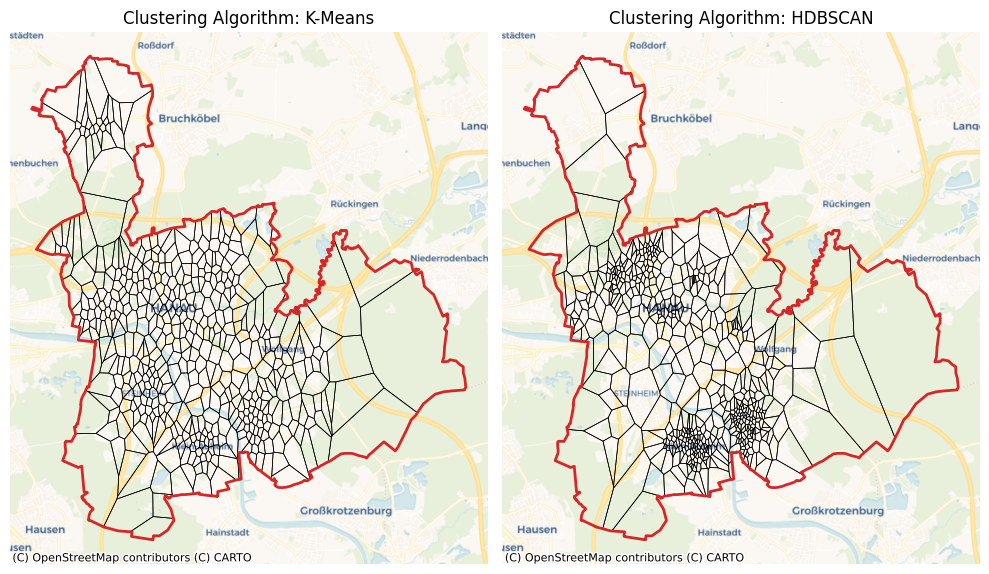

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

hanau_vor_kmeans.to_crs("EPSG:3857").plot(
    ax=axs[0], facecolor="none", edgecolor="k", lw=0.5
)
hanau_vor_hdbscan.to_crs("EPSG:3857").plot(
    ax=axs[1], facecolor="none", edgecolor="k", lw=0.5
)

axs[0].set_title(f"Clustering Algorithm: K-Means")
axs[1].set_title(f"Clustering Algorithm: HDBSCAN")

for ax in axs.flatten():
    ax.set_axis_off()
    ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
    hanau_polygon.to_crs("EPSG:3857").plot(
        ax=ax, facecolor="none", edgecolor="tab:red", lw=2
    )

plt.tight_layout()